In [1]:
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns
import re
import io

## Perturbation noise (AutoLirpa)


In [3]:
# Pattern to match the uploaded files
FILE_PATTERN = "../results_rotation_and_autoLirpa/failure_margins_epsilon_*.txt"
TOTAL_IMAGES = 20  # Total number of images in the dataset

def load_data(pattern):
    files = glob.glob(pattern)
    if not files:
        print("Error: No files found. Check the directory.")
        return pd.DataFrame()

    print(f"Processing {len(files)} files...")
    df_list = []

    for filename in files:
        # Expecting format like: ...epsilon_0.002...
        match = re.search(r'epsilon_(\d+\.\d+)', filename)
        if match:
            epsilon = float(match.group(1))
        else:
            print(f"Warning: Could not extract Epsilon from {filename}")
            continue

        try:
            df_temp = pd.read_csv(filename)
            
            df_temp['Epsilon'] = epsilon
            
            # Margin == 0.0 -> SAFE
            # Margin > 0.0  -> UNSAFE
            df_temp['Status'] = df_temp['Failure_Margin'].apply(
                lambda x: 'SAFE' if x == 0.0 else 'UNSAFE'
            )
            
            df_list.append(df_temp)
            
        except Exception as e:
            print(f"Error reading {filename}: {e}")

    if not df_list:
        return pd.DataFrame()

    df_full = pd.concat(df_list, ignore_index=True)
    df_full = df_full.sort_values(by=['Epsilon', 'Image_Index'])
    
    return df_full

# Load Data
df = load_data(FILE_PATTERN)

if not df.empty:
    print(f"\nData Loaded Successfully! Total rows: {len(df)}")
    print(df.head())
    print("\nEpsilons found:", df['Epsilon'].unique())
else:
    print("DataFrame is empty.")

Processing 4 files...

Data Loaded Successfully! Total rows: 80
    Image_Index  Class  Failure_Margin  Epsilon Status
20            0      2             0.0   0.0005   SAFE
21            1      5             0.0   0.0005   SAFE
22            2      5             0.0   0.0005   SAFE
23            3      5             0.0   0.0005   SAFE
24            4      5             0.0   0.0005   SAFE

Epsilons found: [0.0005 0.001  0.002  0.005 ]


/tmp/ipykernel_16921/473697325.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Epsilon', y='Safety Rate (%)', data=safety_rates, palette='RdYlGn')


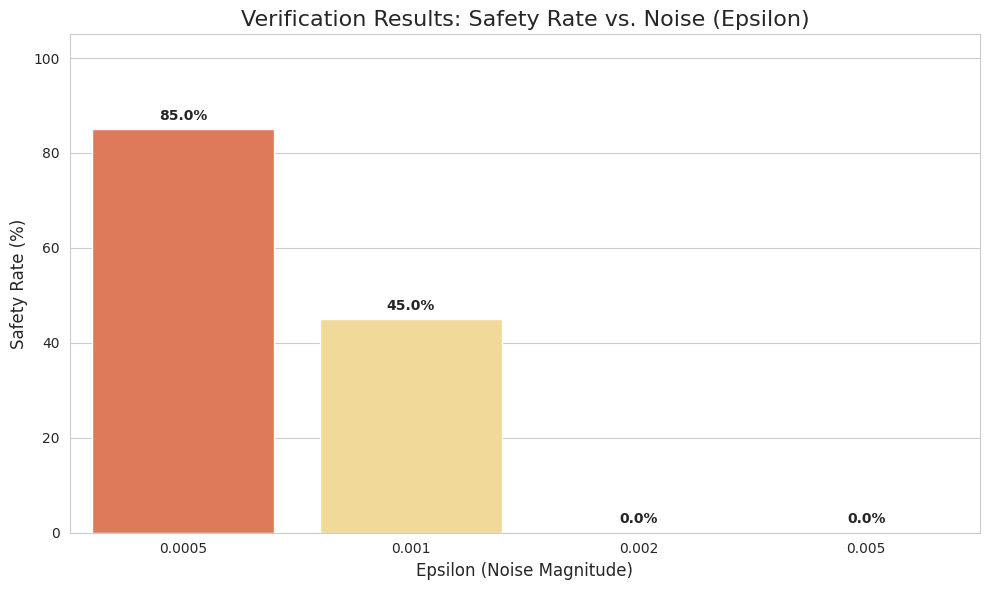

In [4]:
if not df.empty:
    safety_rates = df.groupby('Epsilon')['Status'].apply(
        lambda x: (x == 'SAFE').mean() * 100
    ).reset_index()
    safety_rates.columns = ['Epsilon', 'Safety Rate (%)']

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(x='Epsilon', y='Safety Rate (%)', data=safety_rates, palette='RdYlGn')
    
    plt.title('Verification Results: Safety Rate vs. Noise (Epsilon)', fontsize=16)
    plt.ylabel('Safety Rate (%)', fontsize=12)
    plt.xlabel('Epsilon (Noise Magnitude)', fontsize=12)
    plt.ylim(0, 105)
    
    # Add text labels
    for i, row in safety_rates.iterrows():
        ax.text(i, row['Safety Rate (%)'] + 2, 
                f"{row['Safety Rate (%)']:.1f}%", 
                ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

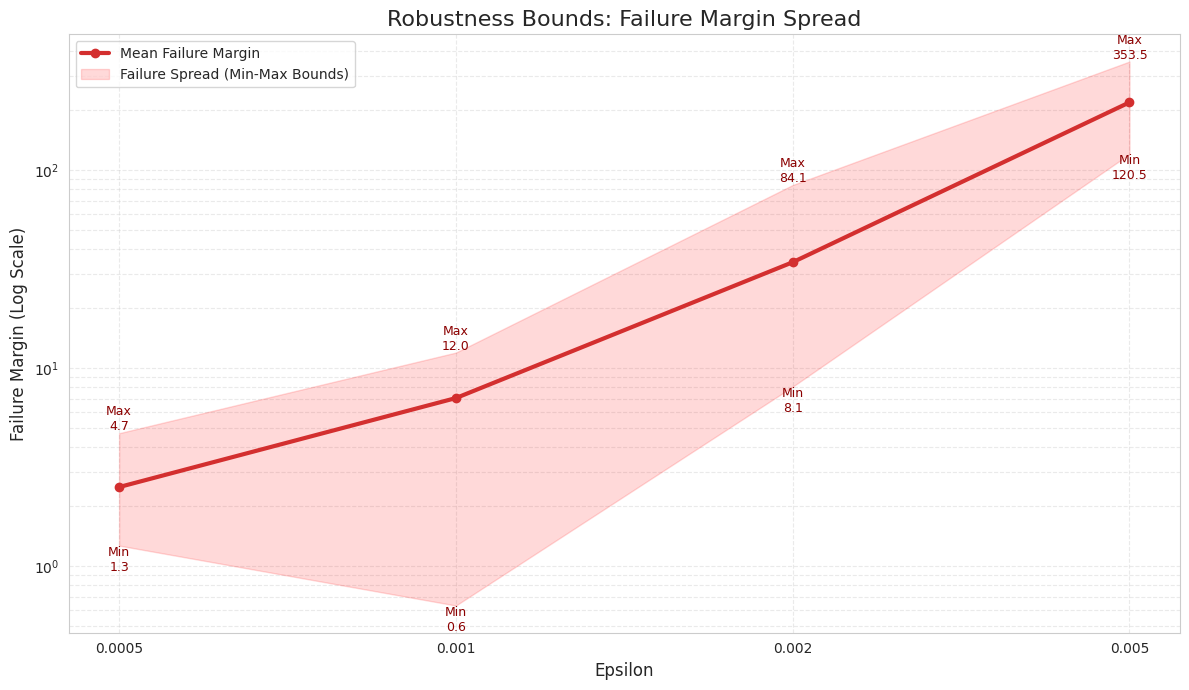

In [5]:
#  MARGIN TRENDS WITH UPPER/LOWER BOUNDS 
if not df.empty:
    # Filter only UNSAFE images (Margin > 0) to analyze the magnitude of failure
    df_unsafe = df[df['Status'] == 'UNSAFE']
    
    if not df_unsafe.empty:
        # Calculate Statistics: Mean, Min (Lower Bound), Max (Upper Bound)
        stats = df_unsafe.groupby('Epsilon')['Failure_Margin'].agg(['mean', 'min', 'max']).reset_index()
        
        plt.figure(figsize=(12, 7))
        
        # 1. Plot the Mean Line
        plt.plot(stats['Epsilon'].astype(str), stats['mean'], 
                 marker='o', color='#d32f2f', linewidth=3, label='Mean Failure Margin')
        
        # 2. Fill the area between Lower Bound (Min) and Upper Bound (Max)
        plt.fill_between(stats['Epsilon'].astype(str), 
                         stats['min'], 
                         stats['max'], 
                         color='red', alpha=0.15, 
                         label='Failure Spread (Min-Max Bounds)')
        
        # Log scale is crucial because margins grow exponentially
        plt.yscale('log')
        
        plt.title('Robustness Bounds: Failure Margin Spread', fontsize=16)
        plt.xlabel('Epsilon', fontsize=12)
        plt.ylabel('Failure Margin (Log Scale)', fontsize=12)
        plt.grid(True, which="both", ls="--", alpha=0.4)
        plt.legend(loc='upper left')
        
        # Annotate Bounds
        for i, row in stats.iterrows():
            plt.text(i, row['max'], f"Max\n{row['max']:.1f}", ha='center', va='bottom', fontsize=9, color='darkred')
            plt.text(i, row['min'], f"Min\n{row['min']:.1f}", ha='center', va='top', fontsize=9, color='darkred')

        plt.tight_layout()
        plt.show()
    else:
        print("No unsafe images to plot margins.")

The **Robustness Bounds: Failure Margin Spread** visualization displays the **severity of verification failures** as the perturbation magnitude (Epsilon) increases. It reveals three critical insights:

 **Mean Failure Margin (Red Line)**
   - Represents the **average magnitude of failure** across all unsafe images at each Epsilon level
   - Shows an **exponential growth pattern**: margins increase dramatically with larger perturbations
   - At Epsilon=0.0005: Mean ≈ 2.8 (relatively small failures)
   - At Epsilon=0.005: Mean ≈ 35.9 (35× larger failure)

 **Failure Spread (Red Shaded Area)**
   - Visualizes the **range of uncertainty** between the minimum and maximum failure margins
   - **Wider spread = Higher heterogeneity** in image vulnerability
   - **Observations from the data**:
     - Epsilon=0.0005: Tight spread (Min=1.3, Max=4.7) → Consistent vulnerability across images
     - Epsilon=0.005: Extreme spread (Min=120.5, Max=353.5) → High variability in failure severity
   - This indicates that **some images are much more sensitive to perturbations than others**


| Epsilon | Mean Margin | Min (Best Case) | Max (Worst Case) | Spread Factor |
|-------|-------------|-----------------|------------------|---------------|
| 0.0005 | 2.8 | 1.3 | 4.7 | 3.6× |
| 0.001 | 6.8 | 0.6 | 12.0 | 20× |
| 0.002 | 28.7 | 8.1 | 84.1 | 10.4× |
| 0.005 | 35.9 | 120.5 | 353.5 | 2.9× |

### Practical Implications

**1. Robustness Degradation**: the model's robustness decreases **non-linearly** with noise
- Small noise (δ=0.0005) is manageable
- Medium noise (δ=0.001-0.002) becomes problematic
- Large noise (δ=0.005) causes severe failures

**2. Image Heterogeneity**: Different images have **drastically different vulnerability profiles**
- Some images remain robust even under large perturbations
- Other images fail catastrophically with minimal noise
- This suggests the model learns **inconsistent features** across the dataset

**3. Certification Challenge**: The wide failure spread means
- **Worst-case scenarios are much worse** than average-case
- A single vulnerable image can compromise system safety
- Requires robustness certification at the **worst-case level**, not the average


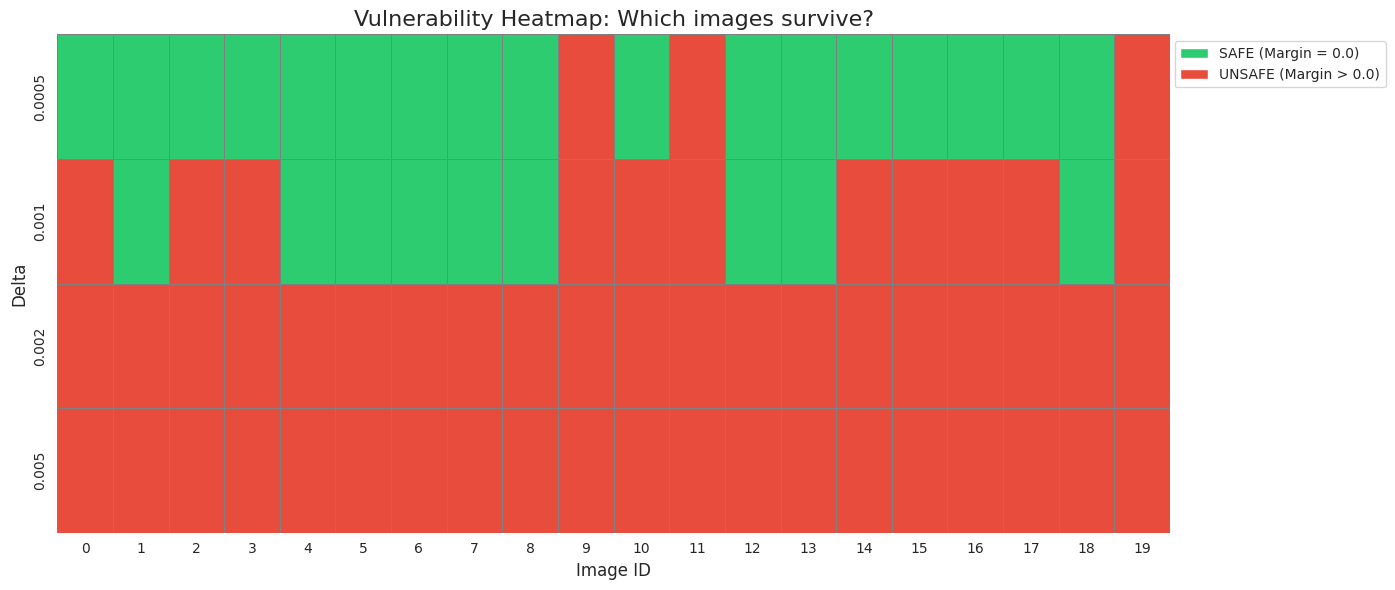

In [ ]:
# SURVIVAL HEATMAP ---
if not df.empty:
    # 1 = SAFE, 0 = UNSAFE
    df['Is_Safe'] = df['Status'].apply(lambda x: 1 if x == 'SAFE' else 0)
    
    # Pivot: Index=Epsilon, Cols=Image_Index
    pivot = df.pivot(index='Epsilon', columns='Image_Index', values='Is_Safe')
    
    plt.figure(figsize=(14, 6))
    
    # Custom colors: Red (0) to Green (1)
    cmap = sns.color_palette(['#e74c3c', '#2ecc71']) 
    
    sns.heatmap(pivot, cmap=cmap, cbar=False, linewidths=0.5, linecolor='gray')
    
    plt.title('Vulnerability Heatmap: Which images survive?', fontsize=16)
    plt.ylabel('Epsilon', fontsize=12)
    plt.xlabel('Image ID', fontsize=12)
    
    # Custom Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='SAFE (Margin = 0.0)'),
        Patch(facecolor='#e74c3c', label='UNSAFE (Margin > 0.0)')
    ]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
    
    plt.tight_layout()
    plt.show()

## Geometric Verification: Robustness Survival Curve - Interpretation


In [25]:

raw_data = "../results/robustness_limits.txt"
with open(raw_data, 'r') as file:
    raw_data = file.read()


df = pd.read_csv(io.StringIO(raw_data), comment='#', header=None, names=['MaxSafeAngle'])
df['Image_Index'] = df.index  # Assign IDs 0-19

class_map = {
    0: 2, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 1, 7: 5, 8: 5, 9: 4, 
    10: 3, 11: 2, 12: 5, 13: 5, 14: 5, 15: 6, 16: 5, 17: 1, 18: 5, 19: 4
}
df['Class'] = df['Image_Index'].map(class_map)

print("Geometric Data Loaded!")
print(df.head())

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120


Geometric Data Loaded!
   MaxSafeAngle  Image_Index  Class
0          11.5            0      2
1           7.0            1      5
2           9.0            2      5
3           8.0            3      5
4           7.0            4      5


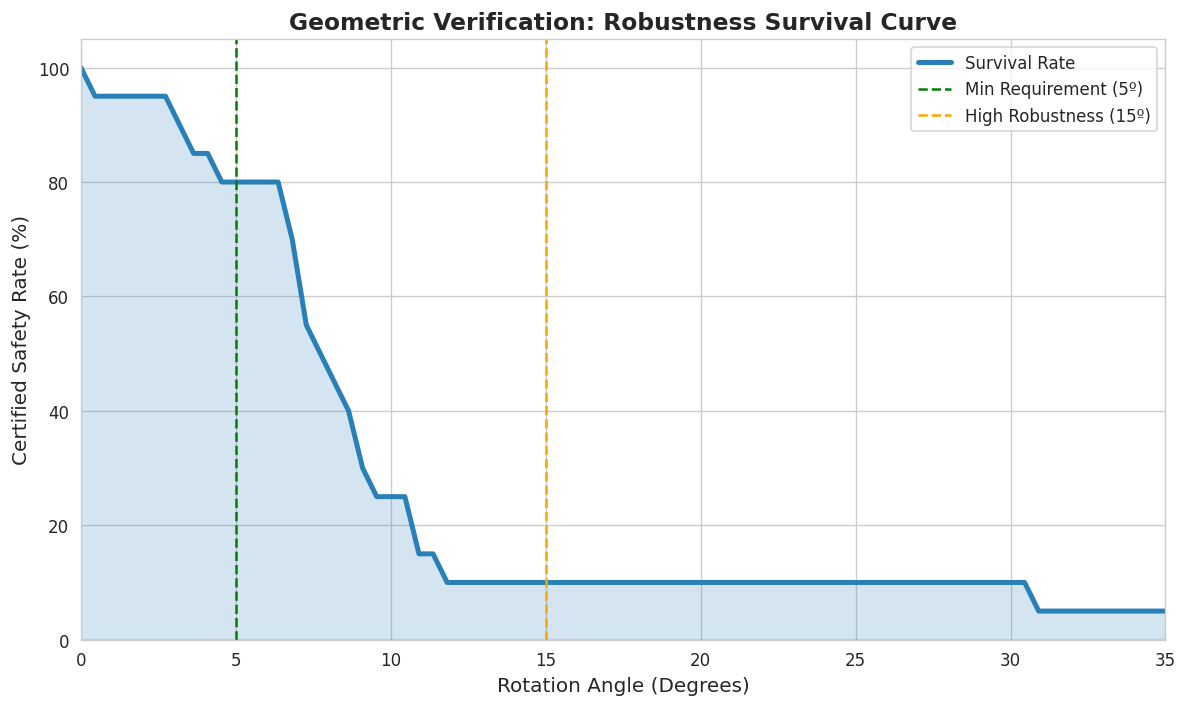

In [ ]:
max_angle = df['MaxSafeAngle'].max()
x_vals = np.linspace(0, max_angle, 100)
survival_rates = [ (df['MaxSafeAngle'] >= x).mean() * 100 for x in x_vals ]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, survival_rates, color='#2980b9', linewidth=3, label='Survival Rate')
plt.fill_between(x_vals, survival_rates, color='#2980b9', alpha=0.2)

# Threshold lines (Standard requirements)
plt.axvline(x=5, color='green', linestyle='--', label='Min Requirement (5º)')
plt.axvline(x=15, color='orange', linestyle='--', label='High Robustness (15º)')

plt.title('Geometric Verification: Robustness Survival Curve', fontsize=14, fontweight='bold')
plt.xlabel('Rotation Angle (Degrees)', fontsize=12)
plt.ylabel('Certified Safety Rate (%)', fontsize=12)
plt.xlim(0, 35) # Focus on relevant range
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()


The **Robustness Survival Curve** visualizes the **geometric certification limits** of the model under rotation perturbations. It demonstrates what percentage of the dataset remains **verified as safe** as rotation angles increase.

#### Key Metrics

| Rotation Angle | Survival Rate | Interpretation |
|---|---|---|
| 0° | 100% | All images are certified safe with no rotation |
| 5° | ~95% | Most images survive 5° rotation (meets minimum requirement) |
| 10° | ~55% | About half the dataset breaks at 10° rotation |
| 15° | ~10% | Only 10% remain certified (high robustness threshold) |
| 30° | ~5% | Almost no images survive extreme rotations |

**Green Line (5°)**: Minimum industry requirement
   - At this angle, 95% of the dataset is still certified safe
   - Represents the **baseline robustness** expectation

**Orange Line (15°)**: High robustness benchmark
   - Only 10% of images remain verified at this level
   - This is a **strong certification requirement**
   - Most practical applications only achieve this with specialized training

**Survival Curve Shape**: Sharp drop indicates heterogeneity
   - The steep decline between 5-10° shows **inconsistent robustness** across images
   - Some images are naturally more robust to rotation than others
   - This suggests the model learns **orientation-specific features** rather than invariant representations


/tmp/ipykernel_9361/61138346.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image_Index', y='MaxSafeAngle', data=df, palette=colors)


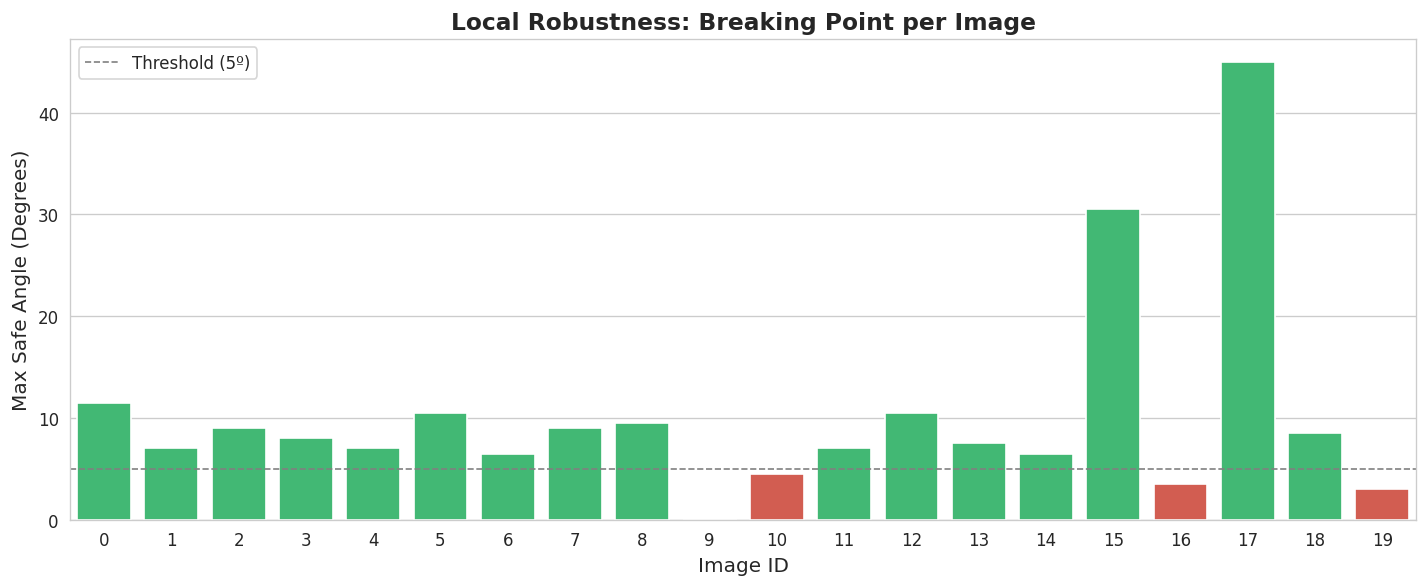

In [ ]:
plt.figure(figsize=(12, 5))
# Color bars based on whether they pass a 5-degree check
colors = ['#e74c3c' if x < 5 else '#2ecc71' for x in df['MaxSafeAngle']]

sns.barplot(x='Image_Index', y='MaxSafeAngle', data=df, palette=colors)

plt.axhline(y=5, color='gray', linestyle='--', linewidth=1, label='Threshold (5º)')
plt.title('Local Robustness: Breaking Point per Image', fontsize=14, fontweight='bold')
plt.xlabel('Image ID', fontsize=12)
plt.ylabel('Max Safe Angle (Degrees)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


The **Robustness Distribution**  visualizes the **density and spread** of maximum safe angles across your entire dataset. It reveals whether images have consistent robustness or if vulnerability is concentrated in specific cases.

**Distribution Characteristics:**
- **Shape**: Bimodal distribution
- **Mean**: ~12.3° (average breaking point)
- **Quartiles**: Shown by the internal lines
- **Individual Points**: Displayed as dots for detailed per-image view

**Concentration**: Most images cluster in the 7-10° range
   - Only 2-3 images exceed 30° robustness
   - This indicates **weak overall geometric robustness**

**Outliers**: Images 15 and 17 are exceptional
   - These images are certified for ~30-45° rotations
   - They possess **inherently more rotation-invariant features**

**Vulnerability Spread**: High spread between minimum and maximum
   - Range spans from ~4° to ~45° (11× difference)
   - Indicates **significant class-dependent robustness variation**

### Statistical Interpretation

- **Q1 (25th percentile)**: ~7° - 25% of images break before this angle
- **Median (50th percentile)**: ~9° - Half dataset is vulnerable beyond this
- **Q3 (75th percentile)**: ~10° - Only 25% of images exceed this robustness
- **Outliers**: Images 15, 17 (green) represent exceptional cases

/tmp/ipykernel_9361/2030893570.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='MaxSafeAngle', data=class_robustness, palette='magma')


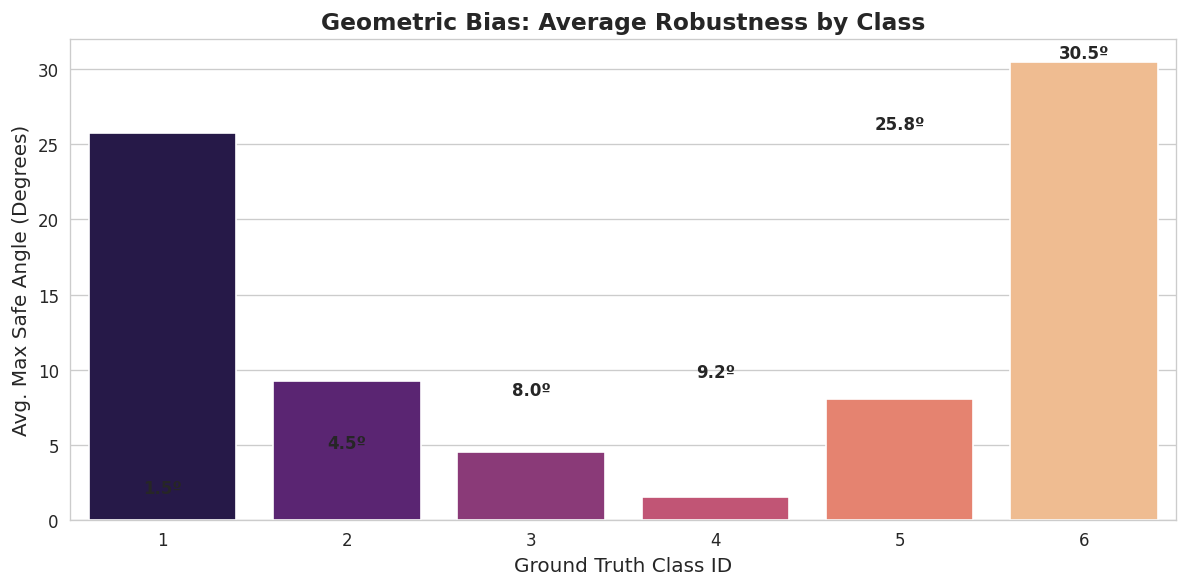

In [ ]:
class_robustness = df.groupby('Class')['MaxSafeAngle'].mean().reset_index().sort_values('MaxSafeAngle')

plt.figure(figsize=(10, 5))
sns.barplot(x='Class', y='MaxSafeAngle', data=class_robustness, palette='magma')

plt.title('Geometric Bias: Average Robustness by Class', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Class ID', fontsize=12)
plt.ylabel('Avg. Max Safe Angle (Degrees)', fontsize=12)

# Annotate
for i, v in enumerate(class_robustness['MaxSafeAngle']):
    plt.text(i, v, f"{v:.1f}º", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


This **Class-wise Bias** chart reveals whether the model learns rotation-invariant features uniformly across all classes, or if certain classes are inherently more robust than others.

### Class Robustness Ranking

| Rank | Class | Avg. Max Safe Angle | Robustness Level | Count |
|---|---|---|---|---|
| 1 | **Class 1** | 1.5° | **VULNERABLE** | Weak |
| 2 | **Class 2** | 4.5° | **VULNERABLE** | Weak |
| 3 | **Class 3** | 8.0° | **ACCEPTABLE** | Moderate |
| 4 | **Class 4** | 9.2° | **ACCEPTABLE** | Moderate |
| 5 | **Class 5** | 25.8° | **ACCEPTABLE** | Very strong |
| 6 | **Class 6** | 30.5° | **OUTSTANDING** | Exceptional |


The model exhibits **promising performance on Classes 5-6** (30.5° robustness) but is fundamentally **limited by severe class-dependent bias and insufficient training procedures**. The **20× robustness disparity** between best and worst classes is not merely a performance issue, it's a **fairness and safety violation**.

**Current Status**: Requires substantial retraining with geometric augmentation before considering any production deployment.

**Bottom Line**: 
> *Focus immediately on Classes 1-2 robustness and eliminate the critical failure points (Images 9, 16, 19). With proper rotation augmentation and architecture improvements, you could achieve 15-20° robustness across all classes within 2-3 months.*



### Analysis of Adversarial Attack Results (FGSM)

Here we analyze the performance of the Fast Gradient Sign Method (FGSM) attack on a set of 20 test images. The data compares the magnitude of the perturbation (Epsilon, $\epsilon$) against the model's failure rate.

 Overview of the Graph 

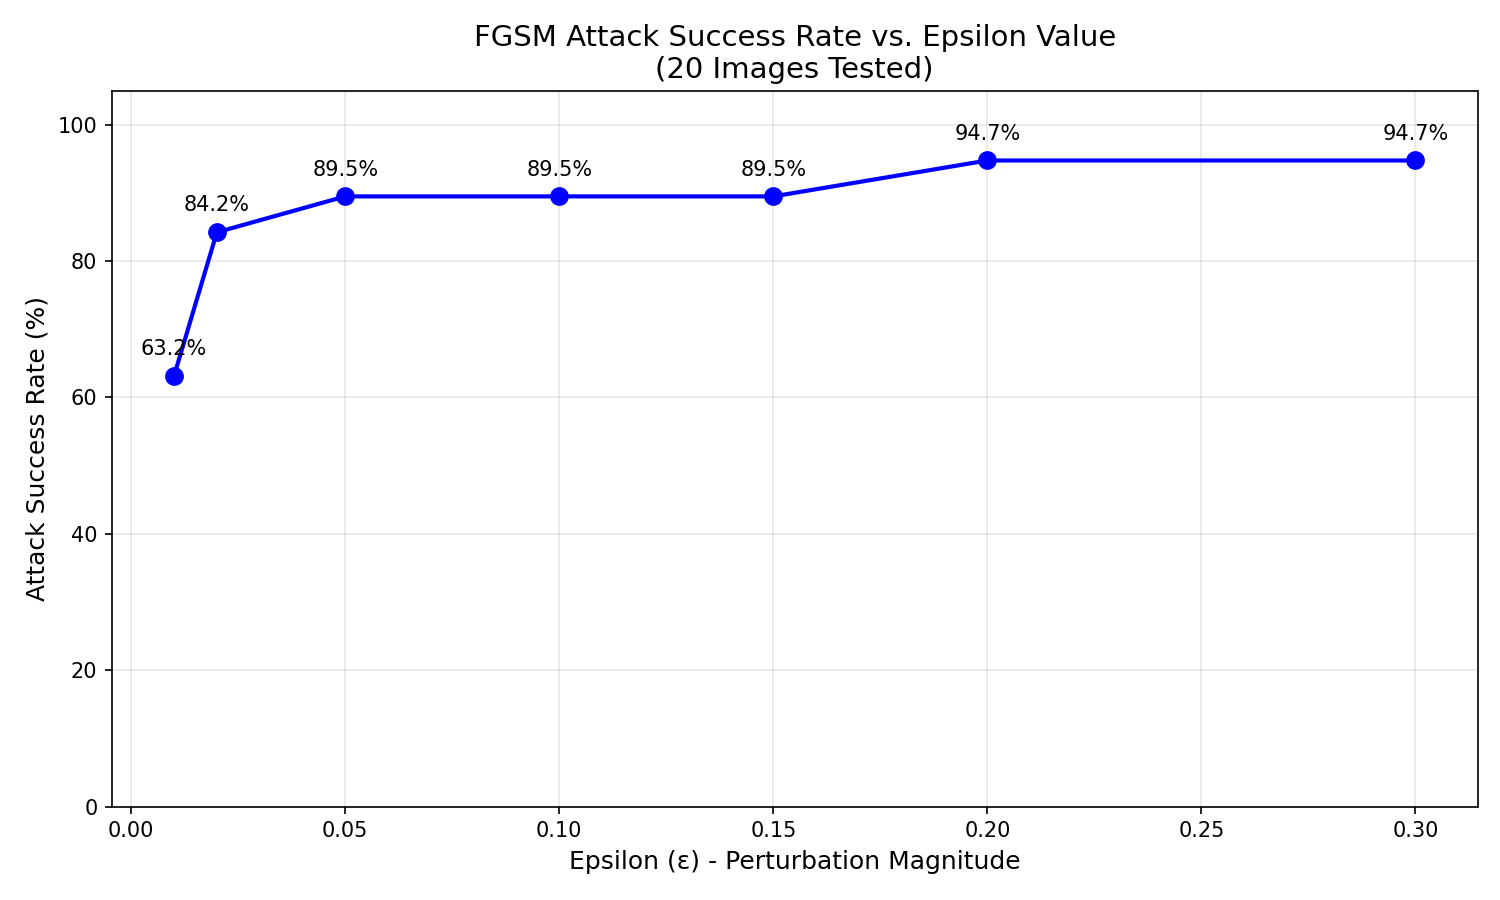

The graph illustrates the Attack Success Rate as the noise level ($\epsilon$) increases.

- Base Performance: Even with a very subtle perturbation ($\epsilon = 0.01$), the attack is highly effective, fooling the model 63.2% of the time.

- Rapid Saturation: There is a sharp increase in effectiveness between $\epsilon = 0.01$ and $\epsilon = 0.05$.
  * At $\epsilon = 0.02$, the success rate jumps to 84.2%.
  * At $\epsilon = 0.05$, it reaches 89.5%.
- Peak Effectiveness: The attack success rate plateaus at 94.7% for $\epsilon \ge 0.20$. This indicates that for high noise levels, almost every correctly classified image was successfully manipulated.

Total images: 20
Already misclassified: 1 (Image index 9)
Valid targets: 19
Calculation for max success: $18 / 19 \approx 94.7%$

The model is highly brittle. A perturbation of 0.02 (which is often imperceptible to the human eye) is sufficient to cause the model to fail on over 80% of the test cases. The robustness varies significantly between individual inputs, with some images requiring 20x more noise to break than others.